In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = sns.load_dataset("mpg")

## 1. Carga `auto_mpg.csv` y realiza el primer contacto con el dataset. Reporta dimensiones, 
primeras filas, tipos de datos y define qué representa una fila. 
Pista de trabajo: `shape`, `head()`, `info()` y `dtypes`. 

In [2]:
df.shape

(398, 9)

In [3]:
df.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [5]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

## 2. Clasifica `mpg`, `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, 
`model_year`, `origin` y `name`. Identifica qué variables, aunque puedan verse numéricas, 
conviene tratar como categorías o variables temporales. 
Pista de trabajo: El significado de una variable es más importante que su dtype.

In [38]:
import pandas as pd
clasificacion_de_variables=pd.DataFrame({"variable":
                                         [ "mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin", "name"],
                                         "Clasificacion":
                                         ["numerica - continua",
                                          "numerica - discreta",
                                          "numerica - continua",
                                          "numerica   - discreta",
                                          "numerica - discreta",
                                          "numerica - discreta",
                                          "numerica - continua",
                                          "categorica - nominal",
                                          "categorica - nominal"]
                                         })
clasificacion_de_variables

,variable,Clasificacion
0,mpg,numerica - continua
1,cylinders,numerica - discreta
2,displacement,numerica - continua
3,horsepower,numerica - discreta
4,weight,numerica - discreta
5,acceleration,numerica - discreta
6,model_year,numerica - continua
7,origin,categorica - nominal
8,name,categorica - nominal


## 3. Analiza valores faltantes y duplicados exactos. ¿En qué variable faltan datos y qué 
proporción representan?  
Pista de trabajo: Para una correlación puntual puedes trabajar con pares completos sin alterar toda la tabla.

In [42]:
valores_nulos=pd.DataFrame({
    "Numeros_nulos":df.isna().sum(),
    "porcentaje" : df.isna().mean() * 100 ,
     
}).sort_values("porcentaje",ascending=False )
print(valores_nulos)

print("-"*20)
print("El numero de duplicados son:",df.duplicated().sum())

              Numeros_nulos  porcentaje
horsepower                6    1.507538
mpg                       0    0.000000
cylinders                 0    0.000000
displacement              0    0.000000
weight                    0    0.000000
acceleration              0    0.000000
model_year                0    0.000000
origin                    0    0.000000
name                      0    0.000000
--------------------
El numero de duplicados son: 0


## 4. Estudia la cardinalidad de `name`. ¿Cuántos nombres distintos hay? ¿Que un nombre 
aparezca varias veces significa que las filas son duplicadas? Compruébalo con ejemplos. 
Pista de trabajo: Un mismo modelo de automóvil puede aparecer en años o configuraciones diferentes. 

In [8]:
cardinalidad_name=df["name"].nunique()
print(cardinalidad_name)

305


In [9]:
contar_nombres = df["name"].value_counts()

print(contar_nombres)

name
ford pinto          6
ford maverick       5
amc matador         5
toyota corolla      5
chevrolet impala    4
                   ..
ford mustang gl     1
vw pickup           1
dodge rampage       1
ford ranger         1
chevy s-10          1
Name: count, Length: 305, dtype: int64


In [10]:
df[df["name"] == "toyota corolla"]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
167,29.0,4,97.0,75.0,2171,16.0,75,japan,toyota corolla
205,28.0,4,97.0,75.0,2155,16.4,76,japan,toyota corolla
321,32.2,4,108.0,75.0,2265,15.2,80,japan,toyota corolla
356,32.4,4,108.0,75.0,2350,16.8,81,japan,toyota corolla
382,34.0,4,108.0,70.0,2245,16.9,82,japan,toyota corolla


## 5. Calcula estadísticos descriptivos de `mpg`, `weight` y `horsepower`: media, mediana, 
desviación estándar, cuartiles e IQR. Interpreta qué te dicen sobre un automóvil “típico” y 
sobre la dispersión. 
Pista de trabajo: Compara medidas sensibles y robustas frente a valores extremos.

In [11]:
## Agregar mediana ,media, y desviacon
resumen=df[["mpg","weight","horsepower"]].agg(["mean","median","std"])
print(resumen)
q=df[["mpg","weight","horsepower"]].quantile([0.25,0.75]).T
q.columns=["q1","q3"]
q["iqr"]=q["q3"]-q["q1"]
q

              mpg       weight  horsepower
mean    23.514573  2970.424623  104.469388
median  23.000000  2803.500000   93.500000
std      7.815984   846.841774   38.491160


,q1,q3,iqr
mpg,17.50,29.0,11.50
weight,2223.75,3608.0,1384.25
horsepower,75.00,126.0,51.00


Observacion: El automóvil típico tiene aproximadamente 23 mpg, un peso de 2803.5 libras y 93.5 HP tomando como referencia la mediana.Además, en weight y horsepower la media es mayor que la mediana, lo que puede indicar la presencia de vehículos con valores altos que elevan la media.

## 6. Analiza la distribución de `mpg` con histograma y KDE.

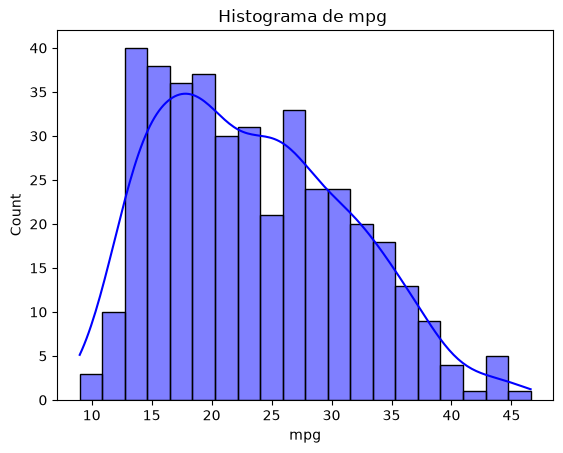

In [12]:
sns.histplot(data=df,x="mpg",bins=20,kde=True,color="b")
plt.title("Histograma de mpg ")
plt.show()

## 7. Analiza `weight` con histograma y boxplot. ¿La distribución es simétrica? ¿Hay valores 
extremos según la regla del IQR? Documenta el cálculo. 
Pista de trabajo: Calcula Q1, Q3, IQR y límites inferior/superior.

             q1      q3      iqr
weight  2223.75  3608.0  1384.25
--------------------------------------------------
Limite inferior weight    147.375
dtype: float64
Limite superior weight    5684.375
dtype: float64


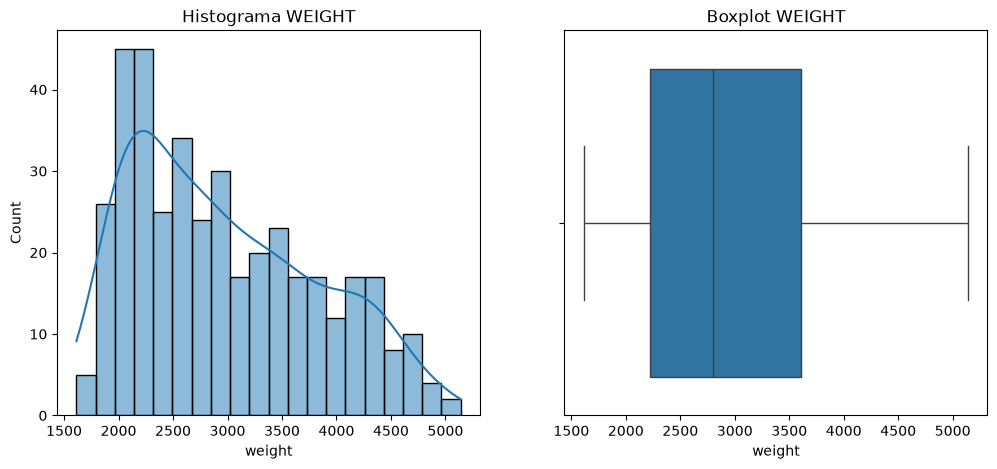

In [13]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.histplot(data=df,x="weight",bins=20,kde=True,ax=axes[0])
axes[0].set_title("Histograma WEIGHT")
sns.boxplot(data=df,x="weight",ax=axes[1])
axes[1].set_title("Boxplot WEIGHT")

q=df[["weight"]].quantile([0.25,0.75]).T
q.columns=["q1","q3"]
q["iqr"]=q["q3"]-q["q1"]
print(q)
print("-"*50)
lower=q["q1"] - 1.5 * q["iqr"]
print("Limite inferior",lower)
upper=q["q3"]+1.5*q["iqr"]
print("Limite superior",upper)


## 8. Detecta outliers en `horsepower` usando 1.5·IQR. Lista los vehículos identificados y 
comenta si parecen errores evidentes o automóviles de alta potencia plausibles.

In [14]:
Q1 = df["horsepower"].quantile(0.25)
Q3 = df["horsepower"].quantile(0.75)
print("Valor de q1",Q1)
print("Valor de q1",Q3)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR
print("Valor maximo",upper)

outliers = df[df["horsepower"] > upper]
outliers

Valor de q1 75.0
Valor de q1 126.0
Valor maximo 202.5


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
13,14.0,8,455.0,225.0,3086,10.0,70,usa,buick estate wagon (sw)
25,10.0,8,360.0,215.0,4615,14.0,70,usa,ford f250
27,11.0,8,318.0,210.0,4382,13.5,70,usa,dodge d200
67,11.0,8,429.0,208.0,4633,11.0,72,usa,mercury marquis
94,13.0,8,440.0,215.0,4735,11.0,73,usa,chrysler new yorker brougham
95,12.0,8,455.0,225.0,4951,11.0,73,usa,buick electra 225 custom
116,16.0,8,400.0,230.0,4278,9.5,73,usa,pontiac grand prix


## 9. Explora `cylinders` y `origin` mediante frecuencias y gráficos de barras. ¿Qué categorías 
dominan el dataset? ¿Hay categorías con muy pocos casos? 
Pista de trabajo: Las categorías poco frecuentes pueden hacer inestables algunas comparaciones. 

In [15]:
df[["origin","cylinders"]]

,origin,cylinders
0,usa,8
1,usa,8
2,usa,8
3,usa,8
4,usa,8
...,...,...
393,usa,4
394,europe,4
395,usa,4
396,usa,4


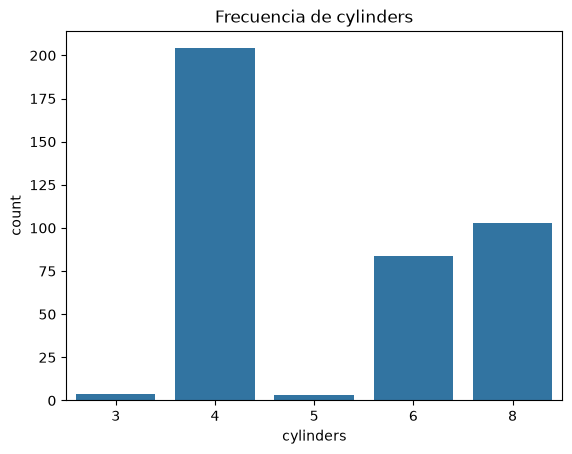

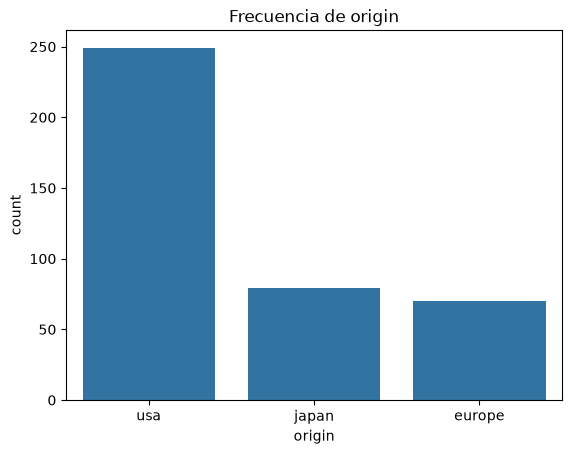

In [16]:
for col in ["cylinders","origin"]:
    sns.countplot(data=df,x=col)
    plt.title(f"Frecuencia de {col}")
    plt.show()

## 10. Compara `mpg` entre vehículos con distinto número de cilindros mediante boxplot y 
medias/medianas por grupo. ¿Qué patrón general observas? 
Pista de trabajo: Ordena los cilindros numéricamente. 

           count       mean  median
cylinders                          
3              4  20.550000   20.25
4            204  29.286765   28.25
5              3  27.366667   25.40
6             84  19.985714   19.00
8            103  14.963107   14.00


Text(0.5, 1.0, 'BOXPLOT N CYLINDERS - MPG')

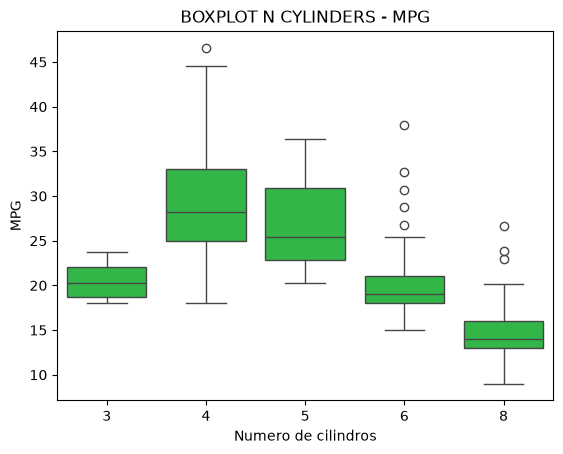

In [17]:
relacion_mpg_cilindros=df.groupby("cylinders")["mpg"].agg(["count","mean","median"])
print(relacion_mpg_cilindros)

sns.boxplot(data=df,x="cylinders",y="mpg",color="#1BCC38")
plt.xlabel("Numero de cilindros")
plt.ylabel("MPG")
plt.title("BOXPLOT N CYLINDERS - MPG")

OBSERVACION: Los datos ooutliers de vehiculos con 6 cilidnros estan fuera de la media, indicando que tiene un MPG singular, este caso se repite en vehiculos de 8 cilindros.

## 11. Compara `mpg` entre los tres orígenes del dataset. Usa boxplot y estadísticas por grupo.  
Pista de trabajo: Las diferencias de origen pueden estar mezcladas con peso, cilindrada, año y otras 
variables. 

        count       mean  median
origin                          
europe     70  27.891429    26.5
japan      79  30.450633    31.6
usa       249  20.083534    18.5


Text(0.5, 1.0, 'BOXPLOT ORIGEN - MPG')

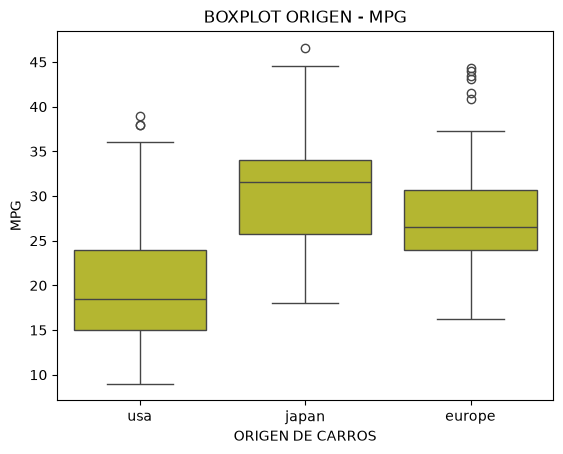

In [18]:
relacion_origin_mpg=df.groupby("origin")["mpg"].agg(["count","mean","median"])
print(relacion_origin_mpg)

sns.boxplot(data=df,x="origin",y="mpg",color="#C9CC1B")
plt.xlabel("ORIGEN DE CARROS")
plt.ylabel("MPG")
plt.title("BOXPLOT ORIGEN - MPG")

## 12. Estudia la relación entre `weight` y `mpg` con un scatterplot y la correlación.

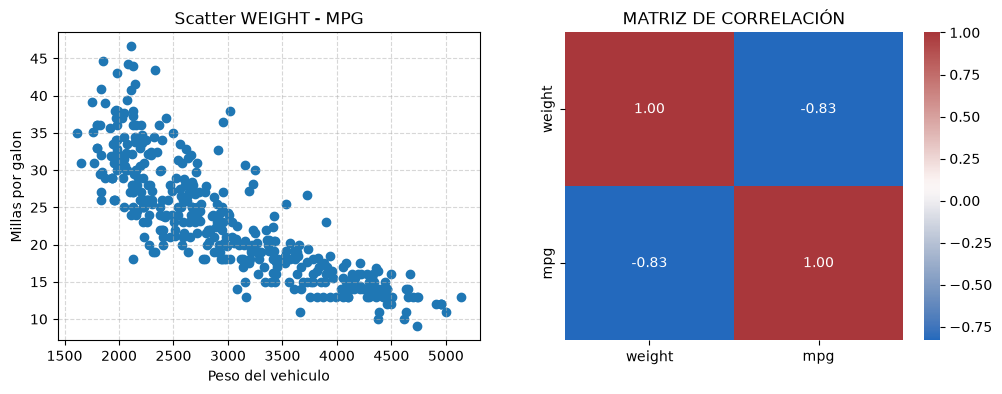

<Figure size 1000x800 with 0 Axes>

In [43]:
#FIGURA 1
dashboard, axes = plt.subplots(1,2 , figsize=(12, 4))

axes[0].scatter(df["weight"],df["mpg"])
axes[0].set_xlabel('Peso del vehiculo')
axes[0].set_ylabel('Millas por galon')
axes[0].set_title('Scatter WEIGHT - MPG')
axes[0].grid(True, linestyle="--", alpha=0.5)
#FIGURA 2 
plt.figure(figsize=(10,8))
corr = df[["weight", "mpg"]].corr()
sns.heatmap(corr,ax=axes[1],annot=True,fmt=".2f",cmap="vlag")
axes[1].set_title("MATRIZ DE CORRELACIÓN")

plt.show()


## 13. Estudia la relación entre `horsepower` y `mpg` con scatterplot y correlación. Compara su 
intensidad con la relación `weight`–`mpg`. 
Pista de trabajo: Trabaja con las filas donde `horsepower` no es nulo.

Text(0.5, 1.0, 'MATRIZ DE CORRELACIÓN')

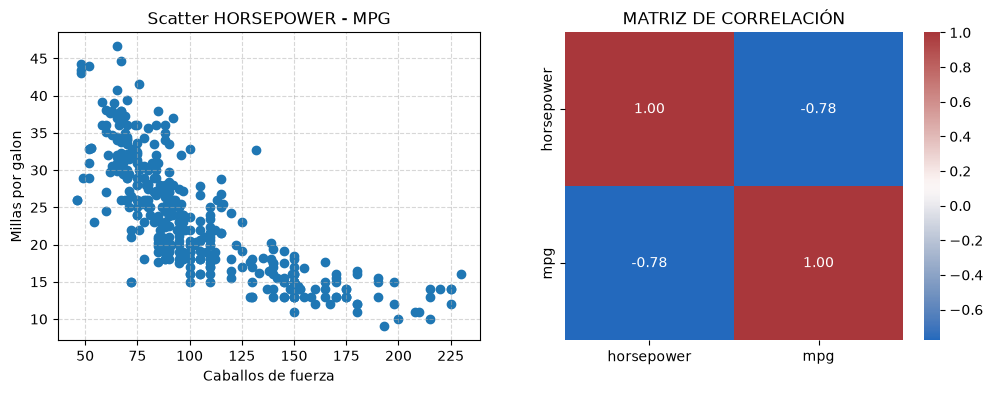

<Figure size 1000x800 with 0 Axes>

In [20]:
# GENERAR UNA COPIA Y ELIMINAR LAS FILAS DE NULO
df_copy=df.copy()
df_copy = df_copy.dropna(subset=["horsepower"])

dashboard, axes = plt.subplots(1,2 , figsize=(12, 4))

axes[0].scatter(df_copy["horsepower"],df_copy["mpg"])
axes[0].set_xlabel('Caballos de fuerza')
axes[0].set_ylabel('Millas por galon')
axes[0].set_title('Scatter HORSEPOWER - MPG')
axes[0].grid(True, linestyle="--", alpha=0.5)
#FIGURA 2 
plt.figure(figsize=(10,8))
corr = df_copy[["horsepower", "mpg"]].corr()
sns.heatmap(corr,ax=axes[1],annot=True,fmt=".2f",cmap="vlag")
axes[1].set_title("MATRIZ DE CORRELACIÓN")




OBSERVACION: Existe una correlacion mas fuerte entre Horsepower y MPG sin contar los datos nulos  que MPG  y Weight.

##  14. Construye una matriz de correlación y heatmap de las variables numéricas. Identifica las 
tres variables con mayor asociación lineal absoluta con `mpg` y comenta posibles 
redundancias entre predictores. 
Pista de trabajo: La matriz es simétrica; no hace falta interpretar dos veces cada pareja

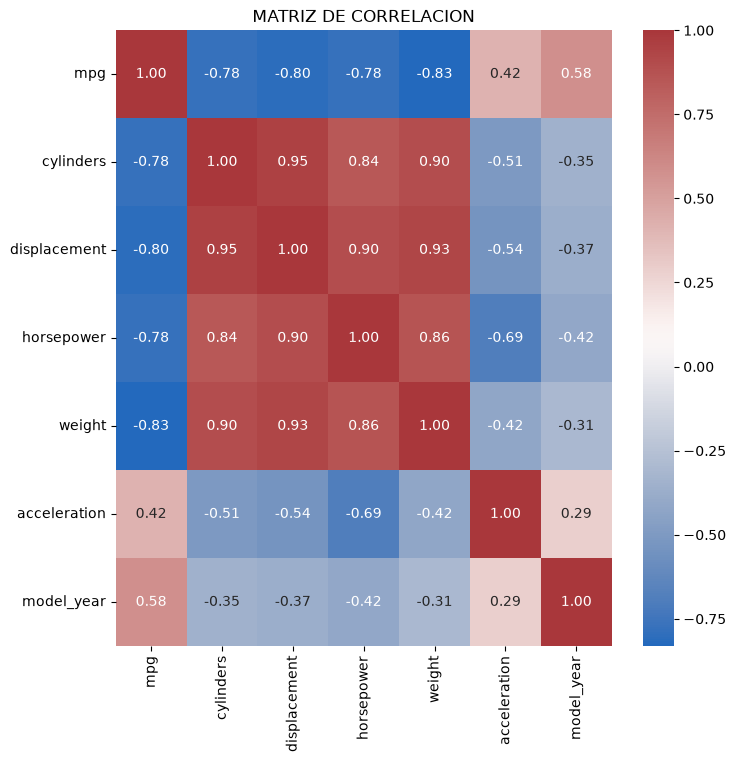

In [33]:
columnas_numericas=df.select_dtypes(include="number")
corr=   columnas_numericas.corr()
plt.figure(figsize=(8,8))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="vlag")
plt.title("MATRIZ DE CORRELACION")
plt.show()

## 15. Realiza un análisis multivariado de `weight` frente a `mpg` incorporando `origin` y 
`cylinders` (mediante color, estilo, facetas u otra codificación). Añade la evolución media de 
`mpg` por `model_year`. 
Pista de trabajo: Busca si el patrón peso–consumo se mantiene dentro de distintos grupos y cómo cambia 
con el tiempo. 

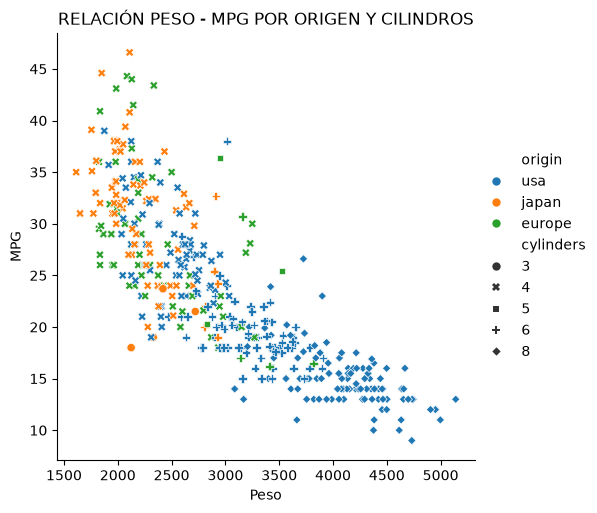

In [22]:
sns.relplot(
    data=df,
    x="weight",
    y="mpg",
    hue="origin",
    style="cylinders",
    kind="scatter"
)

plt.xlabel("Peso")
plt.ylabel("MPG")
plt.title("RELACIÓN PESO - MPG POR ORIGEN Y CILINDROS")

plt.show()

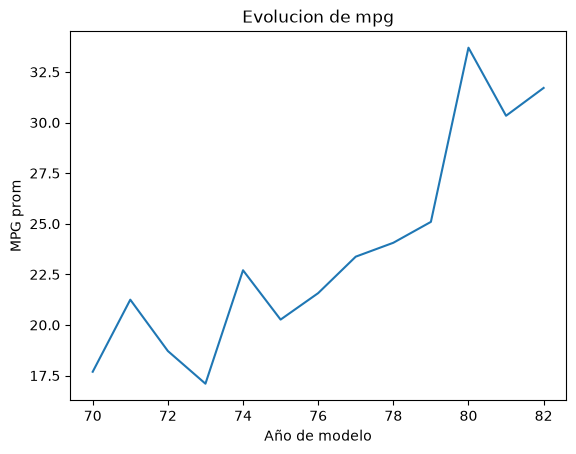

In [23]:
mpg_year = df.groupby("model_year")["mpg"].mean().plot(kind="line")
plt.xlabel("Año de modelo")
plt.ylabel("MPG prom")
plt.title("Evolucion de mpg")
plt.show()

## 16. Analiza la evolución de `mpg` por `model_year`. Calcula media y mediana por año y 
represéntalas en una gráfica de líneas.  
Pista de trabajo: Trata `model_year` como una variable temporal discreta y revisa todos los años, no solo el 
primero y el último. 

                media  mediana
model_year                    
70          17.689655    16.00
71          21.250000    19.00
72          18.714286    18.50
73          17.100000    16.00
74          22.703704    24.00
75          20.266667    19.50
76          21.573529    21.00
77          23.375000    21.75
78          24.061111    20.70
79          25.093103    23.90
80          33.696552    32.70
81          30.334483    31.60
82          31.709677    32.00


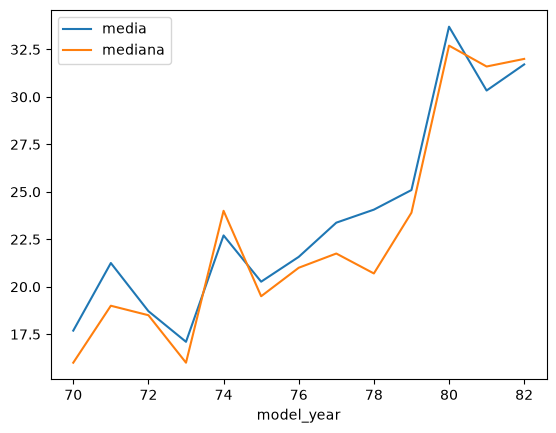

In [24]:
mpg_year = df.groupby("model_year")["mpg"].agg(media="mean",mediana="median")

print(mpg_year)

mpg_year_grafico = df.groupby("model_year")["mpg"].agg(media="mean",mediana="median").plot(kind="line")



## 17. Compara el `weight` de los automóviles por `origin` mediante estadísticas y boxplots. 
¿Puede la diferencia de peso ayudar a explicar parte de las diferencias de `mpg` observadas 
entre orígenes? 
Pista de trabajo: Relaciona este resultado con la fuerte asociación entre peso y consumo observada 
previamente.

              media  mediana
origin                      
europe  2423.300000   2240.0
japan   2221.227848   2155.0
usa     3361.931727   3365.0


<Axes: xlabel='origin', ylabel='weight'>

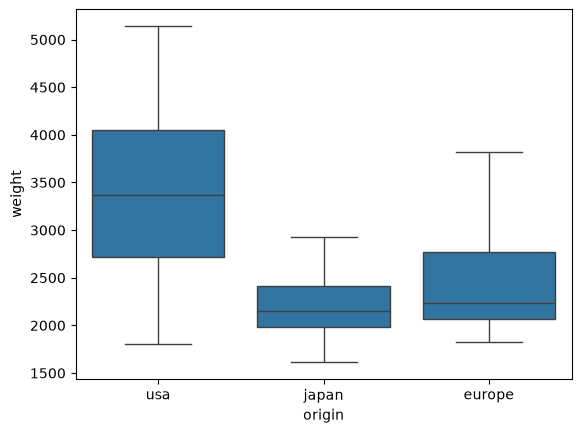

In [25]:
weight_origin = df.groupby("origin")["weight"].agg(media="mean",mediana="median")
print(weight_origin)
sns.boxplot(data=df,x="origin",y="weight")

## 18. Estudia el patrón de los valores faltantes de `horsepower`. Compara su frecuencia por 
`origin`, `cylinders` y `model_year`.  
Pista de trabajo: Con pocos casos faltantes conviene describir el patrón, pero evitar conclusiones fuertes.

In [26]:
df_nulos = df[df["horsepower"].isnull()]
print("-"*20)
print(df_nulos['origin'].value_counts())
print("-"*20)
print(df_nulos['cylinders'].value_counts())
print("-"*20)
print(df_nulos['model_year'].value_counts())


--------------------
origin
usa       4
europe    2
Name: count, dtype: int64
--------------------
cylinders
4    5
6    1
Name: count, dtype: int64
--------------------
model_year
80    2
71    1
74    1
81    1
82    1
Name: count, dtype: int64


## 19. Analiza la relación entre `acceleration` y `mpg` mediante scatterplot y correlación de 
Pearson. Compara su fuerza con las relaciones de `weight` y `horsepower` con `mpg`. 
Pista de trabajo: Una correlación moderada puede aportar información, pero no necesariamente domina el 
comportamiento del objetivo. 

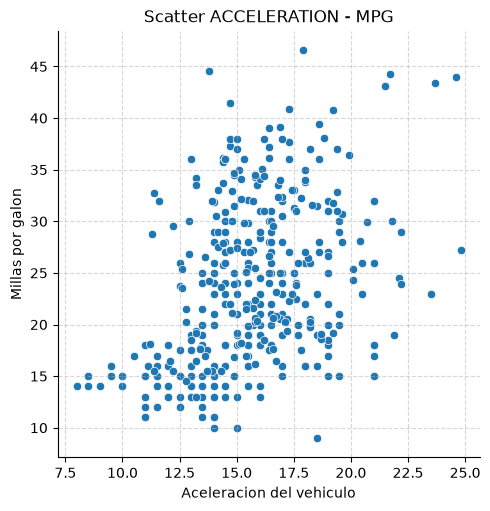

In [27]:
#FIGURA 1
sns.relplot(x=df["acceleration"],y=df["mpg"],kind="scatter")
plt.xlabel('Aceleracion del vehiculo')
plt.ylabel('Millas por galon')
plt.title('Scatter ACCELERATION - MPG')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()



In [28]:
corr = df[["acceleration", "weight", "horsepower", "mpg"]].corr()
print(corr["mpg"])


acceleration    0.420289
weight         -0.831741
horsepower     -0.778427
mpg             1.000000
Name: mpg, dtype: float64


## 20. Explora las relaciones entre `displacement`, `horsepower` y `weight`. Calcula sus 
correlaciones y crea gráficos de dispersión. ¿Qué problema podría aparecer si se usan 
simultáneamente como predictores sin revisar redundancias? 
Pista de trabajo: Correlaciones muy altas entre predictores son una señal de posible multicolinealidad o 
redundancia. 

              displacement  horsepower    weight
displacement      1.000000    0.897257  0.932994
horsepower        0.897257    1.000000  0.864538
weight            0.932994    0.864538  1.000000
----------------------------------------------------------------------------------------------------


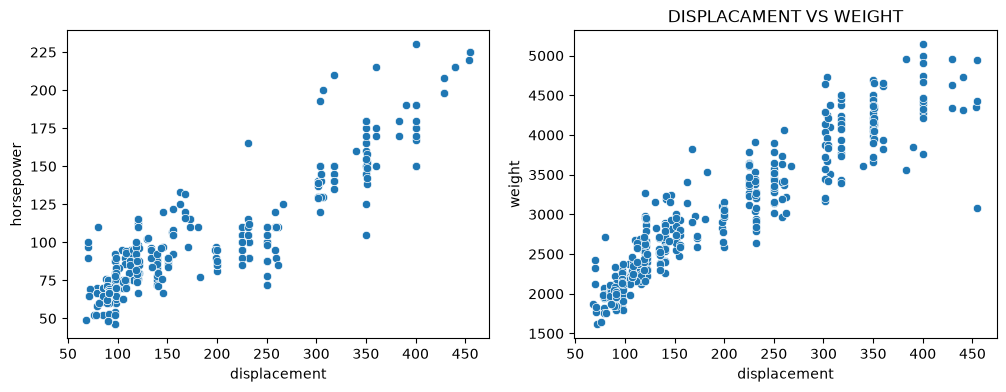

In [29]:
df_nulos = df.dropna(subset=['horsepower'])
print(df_nulos[['displacement', 'horsepower', 'weight']].corr())
print("-"*100)
dashboard, axes = plt.subplots(1,2 , figsize=(12, 4))
sns.scatterplot(data=df_nulos,x='displacement', y='horsepower',ax=axes[0])
plt.title('DISPLACEMENT VS HORSEPOWER')

sns.scatterplot(data=df_nulos,x='displacement', y='weight',ax=axes[1])
plt.title('DISPLACAMENT VS WEIGHT')
plt.show()

## 21. Construye una tabla pivote con el `mpg` medio por `cylinders` y `origin`, incluyendo el 
número de automóviles por grupo. ¿El patrón de cilindros se mantiene dentro de cada origen? 
Señala grupos con muestras pequeñas. 
Pista de trabajo: No interpretes con la misma confianza una media basada en 3 automóviles que otra basada 
en más de 60.

In [30]:
tabla_pivot = df.pivot_table(values="mpg",index="cylinders",columns="origin",aggfunc=["mean", "count"])
tabla_pivot


mean                        count             
origin        europe      japan        usa europe japan    usa
cylinders                                                     
3                NaN  20.550000        NaN    NaN   4.0    NaN
4          28.411111  31.595652  27.840278   63.0  69.0   72.0
5          27.366667        NaN        NaN    3.0   NaN    NaN
6          20.100000  23.883333  19.663514    4.0   6.0   74.0
8                NaN        NaN  14.963107    NaN   NaN  103.0

## 22. Compara la evolución temporal de `mpg` entre `origin` usando líneas por grupo. ¿Los tres 
orígenes mejoran con el tiempo? ¿La brecha entre orígenes permanece constante? 
Pista de trabajo: Una gráfica con `model_year` en x, `mpg` medio en y y una línea por origen permite ver 
interacción entre tiempo y origen. 

    model_year  origin        mpg
0           70  europe  25.200000
1           70   japan  25.500000
2           70     usa  15.272727
3           71  europe  28.750000
4           71   japan  29.500000
5           71     usa  18.100000
6           72  europe  22.000000
7           72   japan  24.200000
8           72     usa  16.277778
9           73  europe  24.000000
10          73   japan  20.000000
11          73     usa  15.034483
12          74  europe  27.000000
13          74   japan  29.333333
14          74     usa  18.333333
15          75  europe  24.500000
16          75   japan  27.500000
17          75     usa  17.550000
18          76  europe  24.250000
19          76   japan  28.000000
20          76     usa  19.431818
21          77  europe  29.250000
22          77   japan  27.416667
23          77     usa  20.722222
24          78  europe  24.950000
25          78   japan  29.687500
26          78     usa  21.772727
27          79  europe  30.450000
28          79

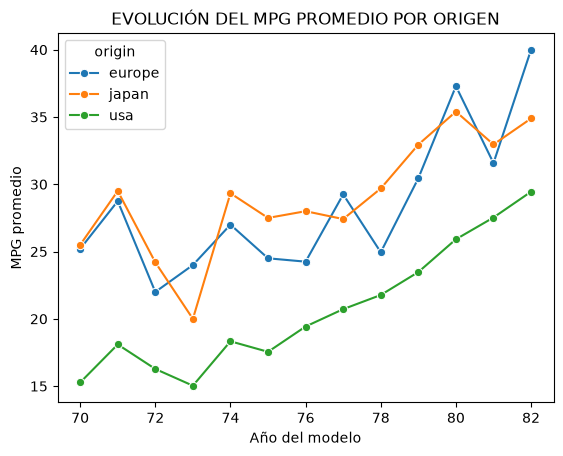

In [31]:
mpg_origen_year = (df.groupby(["model_year", "origin"])["mpg"].mean().reset_index ())
print(mpg_origen_year)

sns.lineplot(data=mpg_origen_year,x="model_year",y="mpg",hue="origin",marker="o")
plt.xlabel("Año del modelo")
plt.ylabel("MPG promedio")
plt.title("EVOLUCIÓN DEL MPG PROMEDIO POR ORIGEN")
plt.show()

## 23. Compara los outliers de `horsepower` detectados mediante 1.5·IQR y mediante |z| > 3. 
Lista los vehículos más extremos y explica por qué un método puede ser más estricto que el 
otro en una distribución asimétrica. 
Pista de trabajo: Comprueba la intersección entre ambos conjuntos de outliers en lugar de asumir que 
producen la misma lista. 


In [36]:
df_nulo = df.dropna(subset=['horsepower']).copy()
Q1 = df_nulo["horsepower"].quantile(0.25)
Q3 = df_nulo["horsepower"].quantile(0.75)
IQR = Q3 - Q1
lower=Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df_nulo[(df_nulo['horsepower'] < lower) | (df_nulo['horsepower'] > upper)]
print("Valor maximo",upper)

mean = df_nulo['horsepower'].mean()
desviacion = df_nulo['horsepower'].std()
df_nulo['z_score'] = (df_nulo['horsepower'] - mean) / desviacion
out_z = df_nulo[df_nulo['z_score'].abs() > 3]

print("Outliers por IQR:")
print(outliers_iqr[['name', 'horsepower']])
print("-"*50)
print("Outliers por z-score:")
print(out_z[['name', 'horsepower']])


Valor maximo 202.5
Outliers por IQR:
                             name  horsepower
6                chevrolet impala       220.0
7               plymouth fury iii       215.0
8                pontiac catalina       225.0
13        buick estate wagon (sw)       225.0
25                      ford f250       215.0
27                     dodge d200       210.0
67                mercury marquis       208.0
94   chrysler new yorker brougham       215.0
95       buick electra 225 custom       225.0
116            pontiac grand prix       230.0
--------------------------------------------------
Outliers por z-score:
                         name  horsepower
6            chevrolet impala       220.0
8            pontiac catalina       225.0
13    buick estate wagon (sw)       225.0
95   buick electra 225 custom       225.0
116        pontiac grand prix       230.0


## 24. Construye un `pairplot` con `mpg`, `weight`, `horsepower`, `displacement` y 
`model_year`, usando `origin` como color

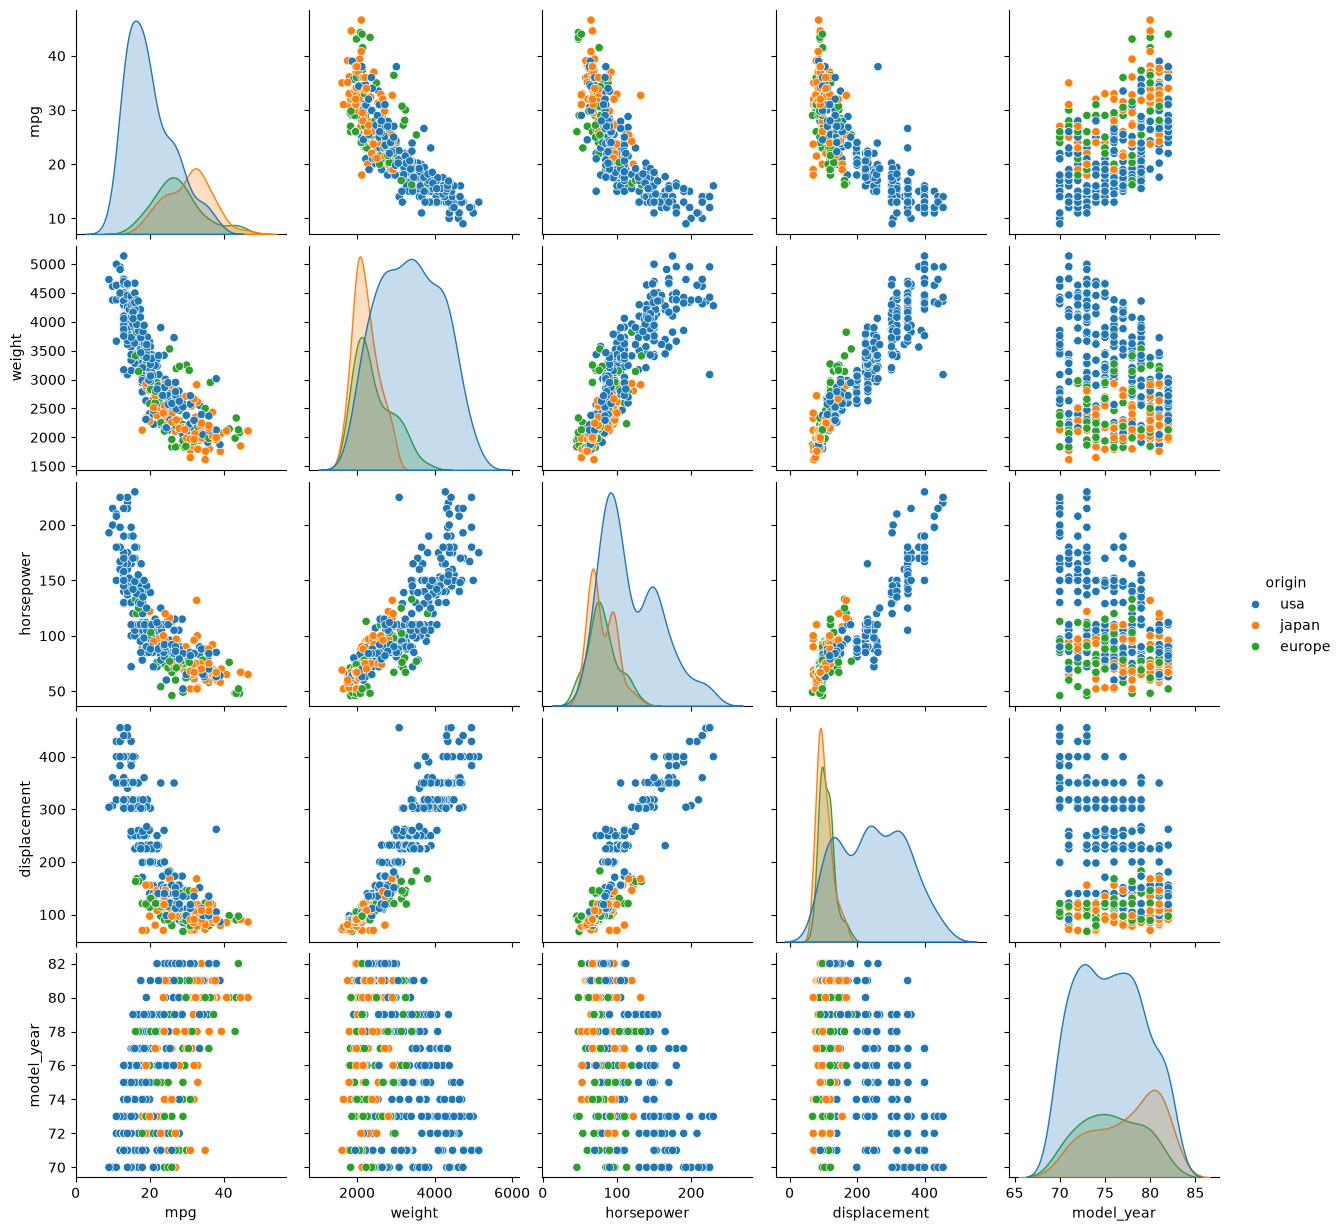

In [37]:
columnas = ['mpg', 'weight', 'horsepower', 'displacement', 'model_year', 'origin']
sns.pairplot(df[columnas].dropna(), hue='origin')
plt.show()

## 25. Elabora un “registro de decisiones” para preparar un análisis posterior: decide qué harías 
con los nulos de `horsepower`, `name`, `origin`, los outliers de potencia y las variables 
altamente correlacionadas. 
Pista de trabajo: Distingue entre decisiones para EDA y decisiones para modelado; una variable útil para 
interpretar puede no ser adecuada como predictor directo.

Durante el EDA trataría de no eliminar los datos de inmediato, sino primero revisar los valores nulos, los valores extremos y las relaciones entre las variables. Para el modelado, decidiría qué hacer con los nulos y outliers dependiendo de cuánto afecten a los datos. También revisaría las variables que tienen mucha relación entre sí para evitar problemas en el modelo.